In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import time
from itertools import combinations
from IPython.display import display

## Introducción

El presente trabajo se basa en el conjunto de datos del censo de vivienda de California de 1990, el cual recopila información demográfica, estructural y geoespacial a nivel de bloque censal. El conjunto de datos permite analizar las características urbanas y socioeconómicas de distintas zonas de California durante la década de los 90, integrando variables como la ubicación geográfica (longitud y latitud), la antigüedad de las construcciones, la población y los ingresos medios.

Objetivo Principal: Predecir de manera precisa el valor mediano de las viviendas (median_house_value) en un determinado sector o bloque censal.

Tipo de Problema: Aprendizaje supervisado de regresión con variable continua (en dólares estadounidenses).

## Descripción del conjunto de datos

Número de observaciones: 20,640 registros.

Número de variables: 10 variables en total, divididas en 9 variables predictoras y 1 variable objetivo.

Significado de la variable objetivo (median_house_value): Representa el valor mediano de la vivienda en un bloque censal específico, expresado en dólares estadounidenses (USD). (Presenta un límite superior o censura en exactamente $500,001, correspondientes a las viviendas que superaban dicho monto).

Tipos de variables:
9 variables de tipo numérico flotante (float64) correspondientes a coordenadas, mediciones estructurales y variables socioeconómicas.
1 variable de tipo categórico de texto (string) que describe la proximidad de la vivienda al mar (ocean_proximity).

-longitude (Numérica, float): Coordenada geográfica que indica la longitud; a menor valor, más al occidente se ubica el sector.

-latitude (Numérica, float): Coordenada geográfica que indica la latitud; a mayor valor, más al norte se ubica el sector.

-housing_median_age (Numérica, float): Antigüedad mediana de las construcciones en el bloque censal (en años).

-total_rooms (Numérica, float): Cantidad total de habitaciones registradas en el bloque. (Aunque corresponde a valores realmente enteros, se almacenan como decimales para facilitar y dar mayor precisión a los cálculos).

-total_bedrooms (Numérica, float): Cantidad total de dormitorios en el bloque censal (207 valores faltantes (equivalente al 1% de los registros de la columna).).

-population (Numérica, float): Cantidad total de residentes que habitan en el bloque.

-households (Numérica, float): Cantidad total de hogares o unidades familiares en el sector.

-median_income (Numérica, float): Ingreso mediano de los hogares en el bloque censal en decenas de miles de dólares 

-median_house_value (Numérica, float — Variable Objetivo): Valor mediano de la vivienda en el bloque (en USD).

-ocean_proximity (Categórica, string): Ubicación de la vivienda con respecto al mar u océano (ej. <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY, ISLAND).

### Posibles limitaciones del conjunto de datos:

-Al tratarse de datos del censo estadounidense de 1990, no reflejan el mercado actual; pero son idóneas para el contexto académico del proyecto

-La variable total_bedrooms cuenta con 207 registros nulos, por lo que se necesita un análisis y una estrategia de imputación antes de entrenar cualquier modelo.

-Múltiples variables predictoras y la propia variable objetivo muestran distribuciones sesgadas y valores extremos o de amplio rango, lo cual se debe tener en cuenta al momento de definir las transformaciones o seleccionar algoritmos tolerantes a estas características.

### Estadísticas descriptivas:

Las variables numéricas reflejan rangos muy amplios; por ejemplo, la población por bloque va desde 3 hasta 35,682 habitantes, y el ingreso mediano (median_income) oscila entre 0.4999 y 15.0001 (en decenas de miles de dólares). Para la variable objetivo (median_house_value), se registra una media de $206,856 USD y una mediana de $179,700 USD, con un rango que parte desde los $14,999 USD hasta el tope de $500,001 USD.

### Distribución de la variable objetivo (median_house_value):

La distribución presenta una marcada asimetría a la derecha. La mayor parte de los valores de las viviendas se concentran entre los $100,000 y $250,000 USD.
Se identifica un límite superior muy marcado en $500,001 USD (con alrededor de 1,000 registros). Esto se debe al censo de 1990.

### Análisis de correlación entre variables numéricas:

median_income presenta la correlación lineal más alta y positiva con el valor de la vivienda (0.69), indicando que el ingreso del bloque censal es el predictor lineal individual más determinante. El resto de las variables numéricas muestran correlaciones lineales relativamente bajas o moderadas con el precio. Por lo que las relaciones no son lineales, lo que nos inclina al uso de modelos basados en árboles. Por otra parte, hay una alta  multicolinealidad entre las variables total_rooms, total_bedrooms, population y households, con coeficientes de correlación de Pearson muy altos entre sí.

### Análisis de las relaciones entre variables predictoras y la variable objetivo:

-Relación geográfica (Longitud y Latitud): Las representaciones geográficas de California demuestran que el valor mediano de la vivienda es considerablemente más alto en zonas costeras. 

-median_income vs. median_house_value: Muestra una relación positiva evidente, acompañada de heterocedasticidad a mayores niveles de ingreso y una concentración persistente de propiedades en el tope de $500,000 USD a lo largo de diversos tramos de ingresos.

-ocean_proximity vs. median_house_value: Los diagramas de caja (boxplots) confirman que las viviendas más costosas se concentran cerca del mar. Se observa que las zonas clasificadas como INLAND concentran las medianas de valor más bajas y un rango acotado, mientras que categorías como <1H OCEAN, NEAR BAY y NEAR OCEAN presentan distribuciones con los bigotes extendidos hacia los límites superior e inferior, además de una alta densidad de valores extremos en los límites superiores de precio.

Encabezado de los datos


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Estadísticas numéricas


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000



Estadísticas categóricas


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136



Valores faltantes


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Estadísticas de median_house_value

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64
Mediana: 179700.0


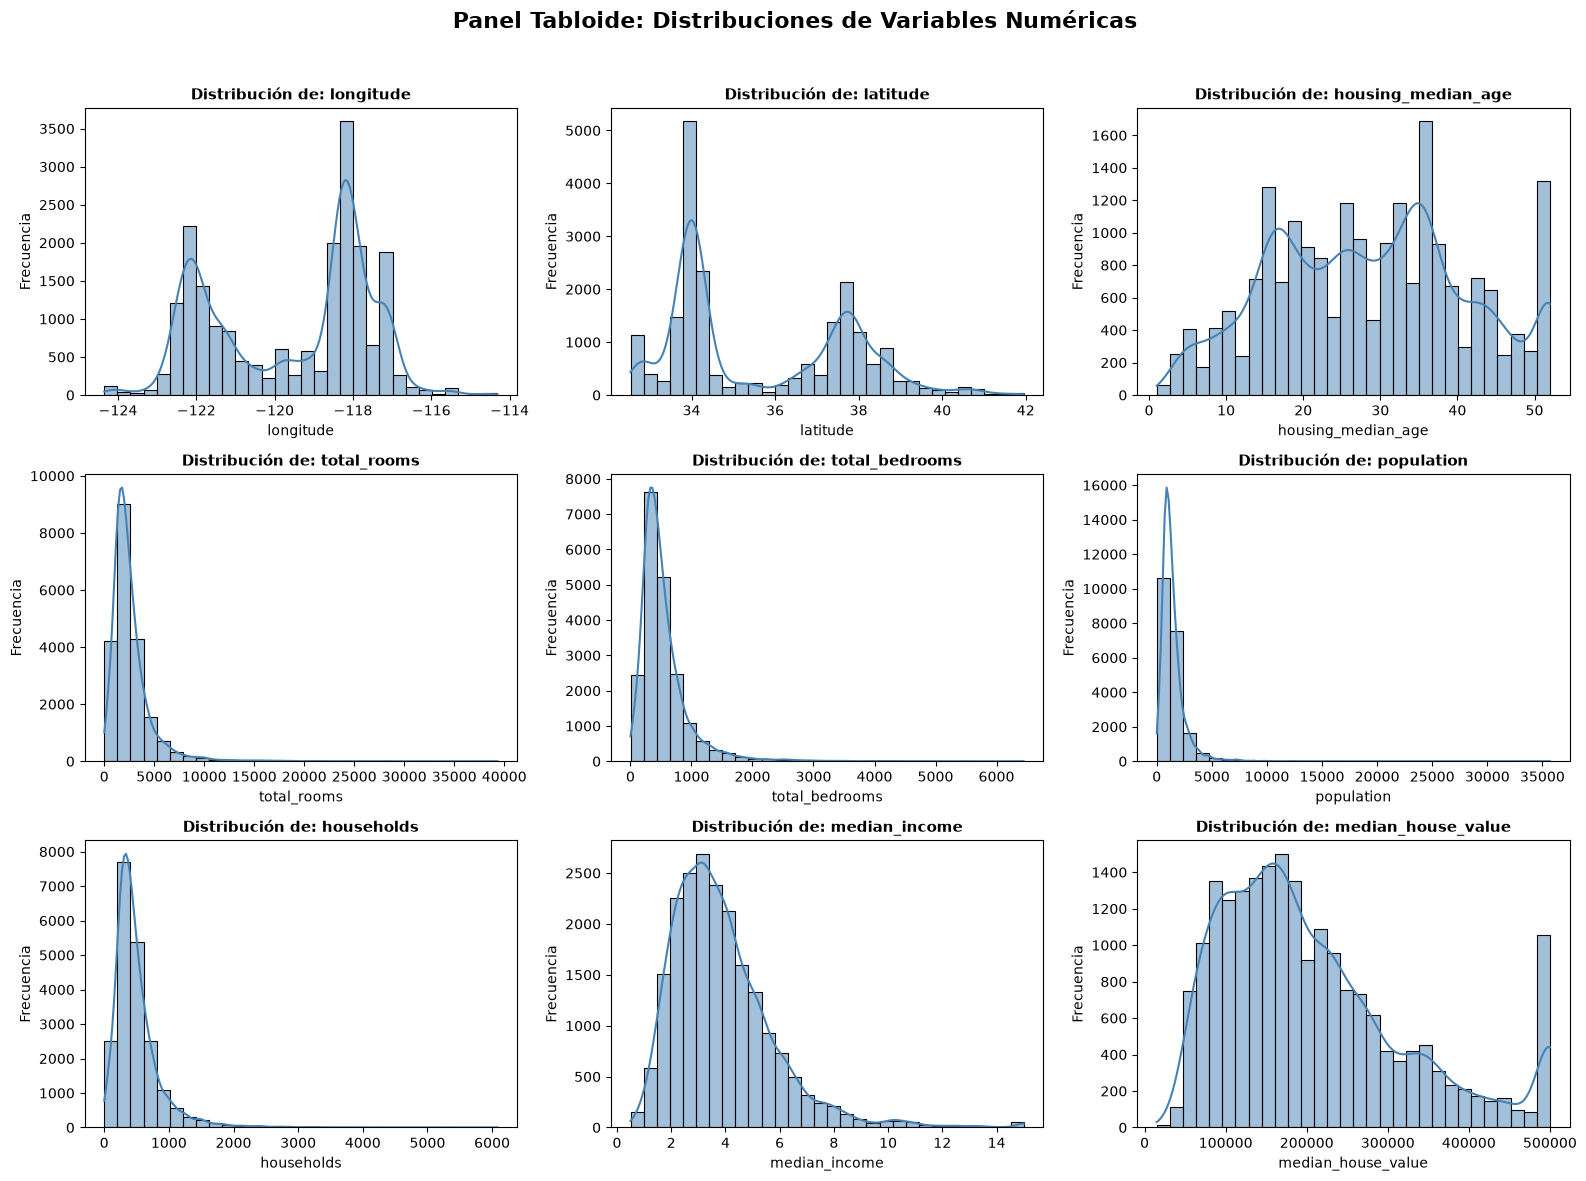

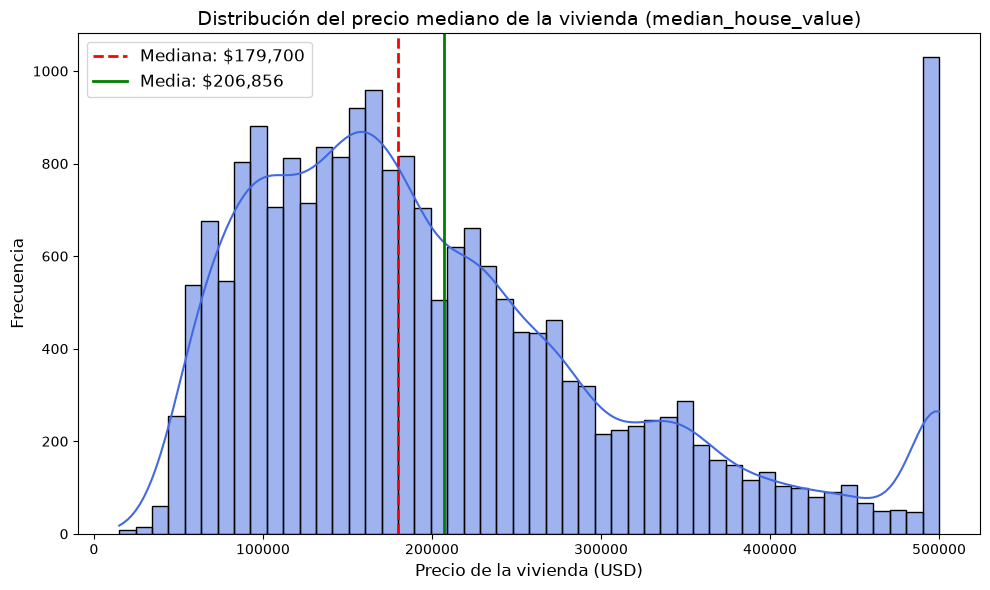

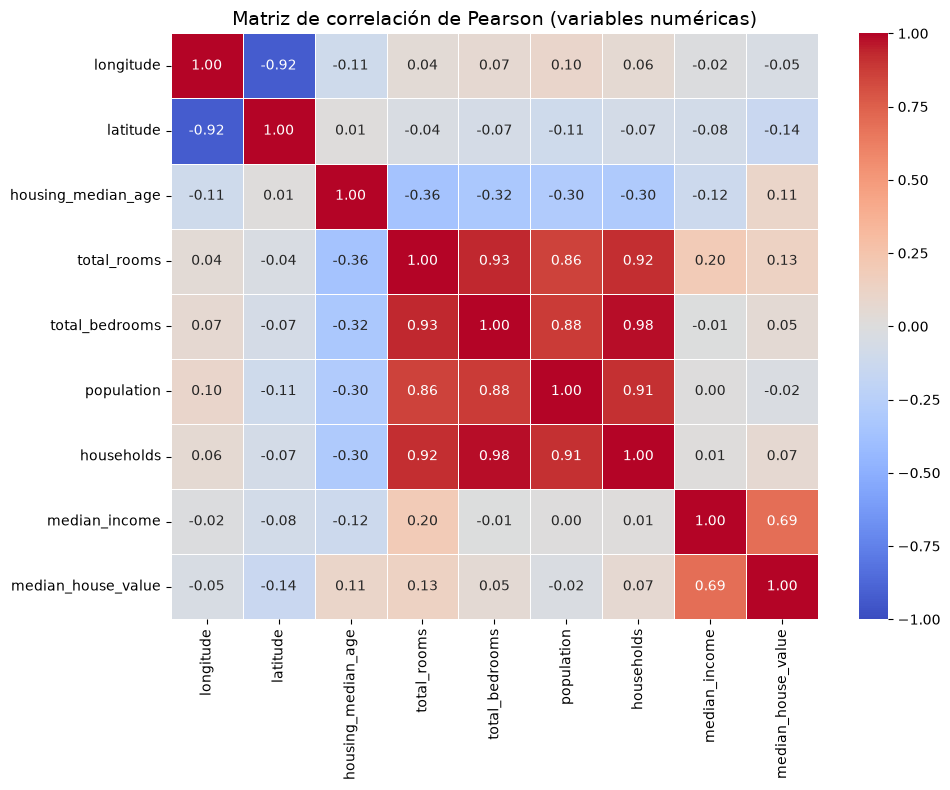

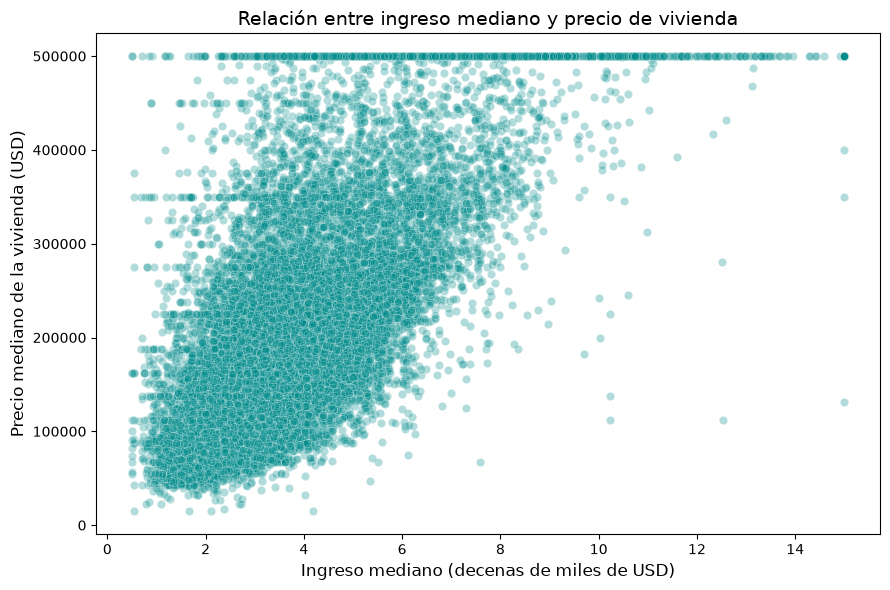

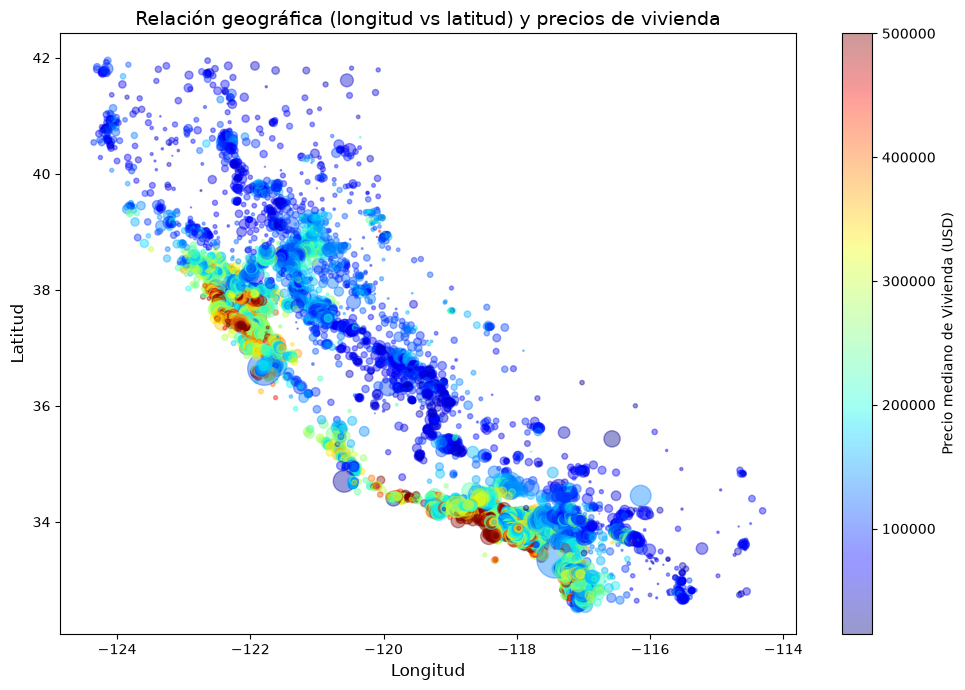

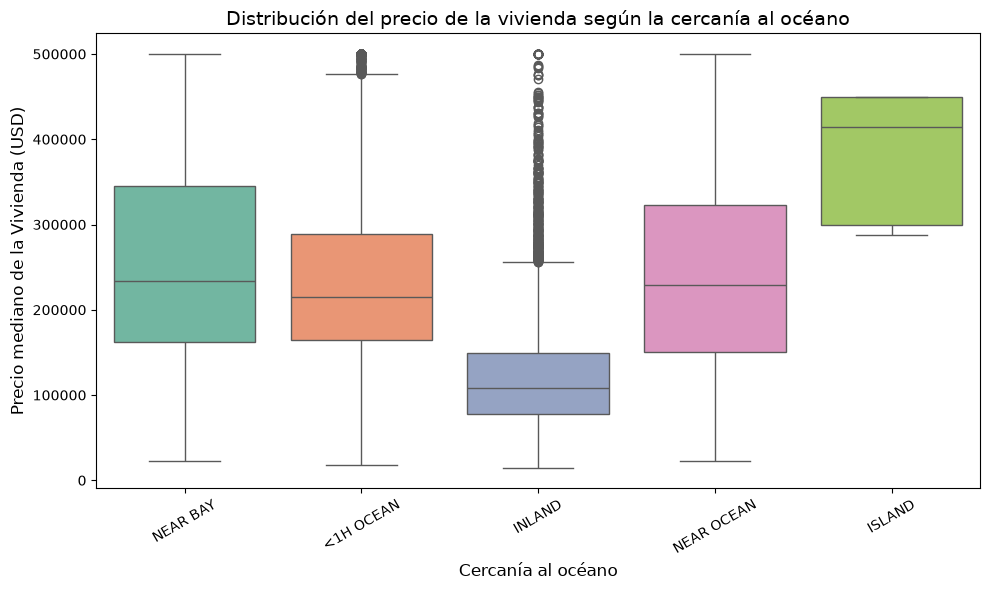

In [2]:
df = pd.read_csv("../data/raw/housing.csv")

print("Encabezado de los datos")
display(df.head())

# Estadísticas numéricas
print("Estadísticas numéricas")
display(df.describe().T)

# Estadísticas descriptivas para la variable categórica (ocean_proximity)
print("\nEstadísticas categóricas")
display(df.describe(include=['str']))

# Conteo de valores nulos por columna
print("\nValores faltantes")
display(df.isnull().sum())

# Estadísticas de median house value en solitario
print("\nEstadísticas de median_house_value\n")
print(df['median_house_value'].describe())
print(f"Mediana: {df['median_house_value'].median()}")

# Definición previa de numeric_df para evitar errores de referencia antes de asignación
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_cols = numeric_df.columns

# Distribución de las Variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribución de: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)

plt.suptitle('Panel Tabloide: Distribuciones de Variables Numéricas', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('numeric_distributions_grid.png', dpi=300)
plt.show()

# Distribución del valor mediano de la vivienda
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, color='royalblue', bins=50)

plt.title('Distribución del precio mediano de la vivienda (median_house_value)', fontsize=14)
plt.xlabel('Precio de la vivienda (USD)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

plt.axvline(df['median_house_value'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: ${df["median_house_value"].median():,.0f}')
plt.axvline(df['median_house_value'].mean(), color='green', linestyle='-', linewidth=2, label=f'Media: ${df["median_house_value"].mean():,.0f}')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlación de Pearson (variables numéricas)', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

# Relación de ingresos con el precio
plt.figure(figsize=(9, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3, color='darkcyan')
plt.title('Relación entre ingreso mediano y precio de vivienda', fontsize=14)
plt.xlabel('Ingreso mediano (decenas de miles de USD)', fontsize=12)
plt.ylabel('Precio mediano de la vivienda (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('income_vs_value.png', dpi=300)
plt.show()

# Relación geográfica y de precios (scatter plot Geográfico)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], alpha=0.4, s=df['population'] / 50, c=df['median_house_value'], cmap='jet')
plt.colorbar(scatter, label='Precio mediano de Vivienda (USD)')
plt.title('Relación geográfica (longitud vs latitud) y precios de vivienda', fontsize=14)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.tight_layout()
plt.savefig('geographic_relations.png', dpi=300)
plt.show()

# Relación de cercanía al océano y precio
plt.figure(figsize=(10, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, hue='ocean_proximity', palette='Set2',legend=False)
plt.title('Distribución del precio de la vivienda según la cercanía al océano', fontsize=14)
plt.xlabel('Cercanía al océano', fontsize=12)
plt.ylabel('Precio mediano de la Vivienda (USD)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('ocean_proximity_vs_value.png', dpi=300)
plt.show()

## Análisis de valores faltantes

Antes de definir una estrategia de tratamiento se cuantifican los nulos y se revisa si los sectores con `total_bedrooms` faltante son distintos al resto. Si lo fueran, eliminarlos o imputarlos con un valor global podría sesgar el modelo.

In [3]:
# Cantidad y porcentaje de nulos por variable
nulos = pd.DataFrame({'nulos': df.isnull().sum(), 'porcentaje': df.isnull().mean() * 100})
display(nulos[nulos['nulos'] > 0])

# Comparación de sectores con y sin nulo en total_bedrooms
con_nulo = df['total_bedrooms'].isnull()
columnas_comparar = ['median_income', 'total_rooms', 'households', 'median_house_value']
display(pd.DataFrame({
    'Mediana con nulo': df.loc[con_nulo, columnas_comparar].median(),
    'Mediana sin nulo': df.loc[~con_nulo, columnas_comparar].median(),
}))
display(pd.concat([
    df.loc[con_nulo, 'ocean_proximity'].value_counts(normalize=True).rename('% con nulo'),
    df.loc[~con_nulo, 'ocean_proximity'].value_counts(normalize=True).rename('% sin nulo'),
], axis=1).mul(100).round(1))

# Redundancia de total_bedrooms con otras variables
print('Correlación total_bedrooms vs total_rooms:', round(df['total_bedrooms'].corr(df['total_rooms']), 3))
print('Correlación total_bedrooms vs households:', round(df['total_bedrooms'].corr(df['households']), 3))

,nulos,porcentaje
total_bedrooms,207,1.002907


,Mediana con nulo,Mediana sin nulo
median_income,3.4115,3.5365
total_rooms,2155.0000,2127.0000
households,427.0000,409.0000
median_house_value,175000.0000,179700.0000


,% con nulo,% sin nulo
ocean_proximity,,
<1H OCEAN,49.3,44.2
INLAND,26.6,31.8
NEAR OCEAN,14.5,12.9
NEAR BAY,9.7,11.1
ISLAND,NaN,0.0


Correlación total_bedrooms vs total_rooms: 0.93
Correlación total_bedrooms vs households: 0.98


**Conclusiones sobre los valores faltantes**

- Solo `total_bedrooms` tiene nulos: 207 registros (1 %).
- Los sectores con nulo tienen medianas de ingreso, tamaño y precio similares al resto, y una distribución de `ocean_proximity` parecida: no se observa un patrón que indique que los faltantes se concentran en un tipo de sector.
- `total_bedrooms` está muy correlacionada con `total_rooms` (0.93) y `households` (0.98), por lo que su información es en gran parte redundante.
- Eliminar las filas perdería el 1 % de los datos sin necesidad y no resolvería nulos en datos nuevos. Por eso se descarta y se opta por imputar o, cuando se justifica por redundancia, eliminar la variable (ver *Preparación de los datos*).

## Preparación de los datos

### Selección de modelos

LightGBM (Modelo Principal): Se selecciona por su alta eficiencia en algoritmos basados en árboles. No requiere transformaciones de escalamiento y gestiona de manera nativa los valores faltantes y la alta variabilidad.

Random Forest Regression (Modelo Alternativo Basado en Árboles): Se considera como modelo de referencia más simple dentro de los ensamblajes de árboles. Requiere codificación one-hot para las variables categóricas e imputación de valores faltantes por la media. Se evalúan variantes con y sin evaluación Out-Of-Bag (OOB).

Support Vector Machines - SVM (Modelo Alternativo de otro paradigma): Se incorpora para comparar el desempeño frente a un modelo de margen y kernel. Necesita la conversión de escalas  y el tratamiento previo de valores faltantes.

### Valores faltantes

-Se detectaron 207 valores faltantes en la   total_bedrooms (equivalente al 1% de los registros), cumpliendo con el requisito de contener nulos para su análisis y tratamiento. Los valores nulos se imputaron utilizando la media de la variable.

-Prevención de fuga: La media para la imputación se calculó estrictamente sobre el conjunto de entrenamiento.

-Estrategia según el modelo y la variante:

  -Variantes completas de Random Forest y SVM: imputación con la media, ajustada solo con entrenamiento.

  -Variantes completas de LightGBM: el algoritmo maneja los valores faltantes de forma nativa, por lo que no requiere imputación.

  -Variantes reducidas (incluido el modelo final): `total_bedrooms` se elimina por su redundancia con `total_rooms` y `households`, por lo que los nulos desaparecen junto con la variable.

### Datos censurados

La variable objetivo (median_house_value) presenta un límite superior artificial en $500,001 USD, donde hay una gran cantidad de registros. Se eliminan las observaciones con valores iguales o superiores a este límite para evitar sesgos.

**Limitación:** como la eliminación se hace antes de la división, el conjunto de prueba tampoco contiene sectores en el tope. Las métricas reportadas corresponden, por tanto, a sectores con valor inferior a $500,001 USD; en uso real no es posible filtrar por el valor (es lo que se quiere predecir), y el modelo nunca predecirá valores por encima de ese rango, por lo que tenderá a subestimar los sectores más costosos.

### Transformación de variable categorial

LightGBM: Soporta la variable ocean_proximity de manera nativa.

Random Forest y SVM: Necesitan la aplicación de One-Hot Encoding para la variable categórica ocean_proximity en columnas binarias, asegurandonos que las categorías estén alineadas entre entrenamiento y prueba sin alterar los valores máximos y mínimos de las variables continuas.

### Crear, eliminar, suplantar y elegir variables

Para reducir la alta multicolinealidad entre total_rooms, total_bedrooms, population y households, se implementan dos aproximaciones complementarias:

Creación de Variables Relativas:

-rooms_per_household: Promedio de habitaciones por hogar (total_rooms / households).

-bedrooms_per_household: Promedio de dormitorios por hogar (total_bedrooms / households).

-population_per_household: Promedio de habitantes por hogar (population / households).

Redundancia entre habitaciones y dormitorios: Como se ve en las distribuciones y matrices de correlación, total_bedrooms se superpone en gran medida con total_rooms. Se contemplará la eliminación de la variable de dormitorios (total_bedrooms / bedrooms_per_household) en favor de la de habitaciones totales (total_rooms / rooms_per_household).

Redundancia de hogares y población: Se evaluará la posibilidad de remover las  de population o households en favor de las nuevas variables de densidad/promedio creadas.

Estrategia de decisión: Mediante regresión stepwise por variaciones de desempeño en los modelos.

### Valoración complementaria de variables geográficas y categóricas:

A diferencia de los conteos de viviendas, las variables geográficas (longitude y latitude) y la variable categórica (ocean_proximity) no son redundantes, sino complementarias.
Las coordenadas geoespaciales aportan la ubicación exacta. Por su parte, ocean_proximity aporta una etiqueta que posee percepciones locales de la ubicación de la vivienda.

### División de datos para entrenamiento y prueba

El conjunto de datos se dividió siguiendo estándares:

-80% del conjunto de datos para entrenamiento.

-20% del conjunto de datos para prueba.

Método de separación: Se utilizó la función de partición estándar fijando una semilla aleatoria.

### Prevención de fuga de información

Aislamiento de la variable objetivo: Se separo median_house_value de las variables predictoras y jamás participó en los cálculos de transformaciones o imputaciones.

Independencia del conjunto de prueba: El conjunto de prueba (20%) no participó en el ajuste de ninguna transformación ni en el entrenamiento de los modelos. El análisis exploratorio se realizó sobre el conjunto completo, pero únicamente con fines descriptivos: de él se obtuvieron decisiones generales (qué variables crear, eliminar o codificar), no parámetros ajustados a los datos.

Ajuste de Transformaciones Exclusivamente en Train:

-Los parámetros de imputación se calcularon únicamente con los datos de entrenamiento y se aplicaron por transformación al conjunto de prueba.

-Los escalamientos requeridos para el modelo SVM se ajustaron solo en el conjunto de entrenamiento y se proyectaron en la prueba.

-La codificación one-hot y los límites de los rangos de las variables se parametrizaron con base en el set de entrenamiento.


## Modelo base

Implementación de DummyRegressor

### Criterio de Evaluación

La calidad del modelo base  se evalúa por su utilidad como umbral de comparación. Cualquier modelo deberá superar significativamente las métricas de error obtenidas por DummyRegressor y las de los otros modelos y sus variantes para justificar su implementación en el proyecto.

In [4]:
# Cargar datos y retirar valores censurados
datos = pd.read_csv('../data/raw/housing.csv')
datos_limpios = datos[datos['median_house_value'] < 500001].copy()

caracteristicas = datos_limpios.drop(columns=['median_house_value'])
objetivo = datos_limpios['median_house_value']


# División de prueba y entrenamiento
X_ent, X_pru, y_ent, y_pru = train_test_split(
    caracteristicas, objetivo, test_size=0.20, random_state=42
)


# Agregar, sustituir o eliminar variables
def agregar_caracteristicas(df_entrada):
    df_salida = df_entrada.copy()
    df_salida['rooms_per_household'] = df_salida['total_rooms'] / df_salida['households']
    df_salida['bedrooms_per_household'] = df_salida['total_bedrooms'] / df_salida['households']
    df_salida['population_per_household'] = df_salida['population'] / df_salida['households']
    return df_salida

X_ent_caract = agregar_caracteristicas(X_ent)
X_pru_caract = agregar_caracteristicas(X_pru)

columnas_eliminar = ['total_bedrooms', 'bedrooms_per_household', 'population', 'households']
X_ent_reducido = X_ent_caract.drop(columns=columnas_eliminar)
X_pru_reducido = X_pru_caract.drop(columns=columnas_eliminar)


# Preparación de modelos y sus variantes
def procesar_conjuntos_datos(df_ent_in, df_pru_in):

    # LightGBM: categorización Nativa (sin OHE)
    X_ent_lgb = df_ent_in.copy()
    X_pru_lgb = df_pru_in.copy()
    X_ent_lgb['ocean_proximity'] = X_ent_lgb['ocean_proximity'].astype('category')
    X_pru_lgb['ocean_proximity'] = X_pru_lgb['ocean_proximity'].astype('category')

    # Random Forest y SVM: imputación y OHE
    columnas_numericas = [c for c in df_ent_in.columns if c != 'ocean_proximity']
    
    imputador = SimpleImputer(strategy='mean')
    X_ent_num_imp = pd.DataFrame(
        imputador.fit_transform(df_ent_in[columnas_numericas]), 
        columns=columnas_numericas, 
        index=df_ent_in.index
    )
    X_pru_num_imp = pd.DataFrame(
        imputador.transform(df_pru_in[columnas_numericas]), 
        columns=columnas_numericas, 
        index=df_pru_in.index
    )

    codificador_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe_ent = pd.DataFrame(
        codificador_ohe.fit_transform(df_ent_in[['ocean_proximity']]), 
        columns=codificador_ohe.get_feature_names_out(['ocean_proximity']), 
        index=df_ent_in.index
    )
    ohe_pru = pd.DataFrame(
        codificador_ohe.transform(df_pru_in[['ocean_proximity']]), 
        columns=codificador_ohe.get_feature_names_out(['ocean_proximity']), 
        index=df_pru_in.index
    )

    # Random Forest (imputación y OHE)
    X_ent_rf = pd.concat([X_ent_num_imp, ohe_ent], axis=1)
    X_pru_rf = pd.concat([X_pru_num_imp, ohe_pru], axis=1)

    # SVM (escalado y OHE)
    escalador = StandardScaler()
    X_ent_escalado = pd.DataFrame(
        escalador.fit_transform(X_ent_num_imp), 
        columns=columnas_numericas, 
        index=df_ent_in.index
    )
    X_pru_escalado = pd.DataFrame(
        escalador.transform(X_pru_num_imp), 
        columns=columnas_numericas, 
        index=df_pru_in.index
    )

    X_ent_svm = pd.concat([X_ent_escalado, ohe_ent], axis=1)
    X_pru_svm = pd.concat([X_pru_escalado, ohe_pru], axis=1)

    return (X_ent_lgb, X_pru_lgb), (X_ent_rf, X_pru_rf), (X_ent_svm, X_pru_svm)

# Generación de variantes procesadas
(X_ent_lgb_c, X_pru_lgb_c), (X_ent_rf_c, X_pru_rf_c), (X_ent_svm_c, X_pru_svm_c) = procesar_conjuntos_datos(X_ent_caract, X_pru_caract)
(X_ent_lgb_r, X_pru_lgb_r), (X_ent_rf_r, X_pru_rf_r), (X_ent_svm_r, X_pru_svm_r) = procesar_conjuntos_datos(X_ent_reducido, X_pru_reducido)


# Construcción de modelos y desempeño
resultados = {}
predicciones = {}

def evaluar_modelo(modelo, nombre_modelo, X_ent_mod, X_pru_mod):
    # Medición de tiempo de ajuste
    tiempo_inicio_fit = time.time()
    modelo.fit(X_ent_mod, y_ent)
    tiempo_fit = time.time() - tiempo_inicio_fit

    # Predicción en entrenamiento y prueba
    prediccion_ent = modelo.predict(X_ent_mod)
    
    tiempo_inicio_pred = time.time()
    prediccion_pru = modelo.predict(X_pru_mod)
    tiempo_pred = time.time() - tiempo_inicio_pred

    # Cálculo de métricas en entrenamiento y prueba
    rmse_ent = np.sqrt(mean_squared_error(y_ent, prediccion_ent))
    rmse_pru = np.sqrt(mean_squared_error(y_pru, prediccion_pru))
    r2_ent = r2_score(y_ent, prediccion_ent)
    r2_pru = r2_score(y_pru, prediccion_pru)
    mae_pru = mean_absolute_error(y_pru, prediccion_pru)

    # Brecha de sobreajuste (diferencia de RMSE relativo en %)
    sobreajuste_rmse_porcentaje = ((rmse_pru - rmse_ent) / rmse_ent) * 100

    predicciones[nombre_modelo] = prediccion_pru
    resultados[nombre_modelo] = {
        'MAE Prueba': round(mae_pru, 2),
        'RMSE Entren.': round(rmse_ent, 2),
        'RMSE Prueba': round(rmse_pru, 2),
        'R2 Entren.': round(r2_ent, 4),
        'R2 Prueba': round(r2_pru, 4),
        'Sobreajuste RMSE (%)': round(sobreajuste_rmse_porcentaje, 2),
        'Tiempo Fit (s)': round(tiempo_fit, 4),
        'Tiempo Predict (s)': round(tiempo_pred, 4)
    }

# Dummy
evaluar_modelo(DummyRegressor(strategy='mean'), 'Dummy Baseline', X_ent, X_pru)

#LightGBM (sin OHE y categórica Nativa)
evaluar_modelo(lgb.LGBMRegressor(random_state=42, verbose=-1), 'LightGBM (Completo)', X_ent_lgb_c, X_pru_lgb_c)
evaluar_modelo(lgb.LGBMRegressor(random_state=42, verbose=-1), 'LightGBM (Reducido)', X_ent_lgb_r, X_pru_lgb_r)

#Random Forest (con OHE)
evaluar_modelo(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), 'Random Forest (Completo)', X_ent_rf_c, X_pru_rf_c)
evaluar_modelo(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), 'Random Forest (Reducido)', X_ent_rf_r, X_pru_rf_r)

# SVM (con OHE y escalamiento)
evaluar_modelo(SVR(kernel='rbf', C=1000), 'SVM (Completo)', X_ent_svm_c, X_pru_svm_c)
evaluar_modelo(SVR(kernel='rbf', C=1000), 'SVM (Reducido)', X_ent_svm_r, X_pru_svm_r)

# Resultados comparativos
print("EVALUACIÓN DE EFECTIVIDAD, SOBREAJUSTE Y TIEMPO DE EJECUCIÓN")
tabla_resultados = pd.DataFrame(resultados).T
print(tabla_resultados.to_string())


# 8. Pruebas de hipótesis cruzadas entre todos los modelos y variantes

print("PRUEBAS DE HIPÓTESIS CRUZADAS")

lista_modelos_evaluados = list(predicciones.keys())
resultados_hipotesis = []

for modelo_1, modelo_2 in combinations(lista_modelos_evaluados, 2):
    error_1 = np.abs(y_pru - predicciones[modelo_1])
    error_2 = np.abs(y_pru - predicciones[modelo_2])
    
    estadistico_t, p_valor_t = stats.ttest_rel(error_1, error_2)
    estadistico_w, p_valor_w = stats.wilcoxon(error_1, error_2)
    
    resultados_hipotesis.append({
        'Modelo 1': modelo_1,
        'Modelo 2': modelo_2,
        'p-valor t-test': f"{p_valor_t:.4e}",
        'p-valor Wilcoxon': f"{p_valor_w:.4e}",
        'Diferencia Significativa (alpha=0.05)': "Sí" if p_valor_w < 0.05 else "No"
    })

tabla_hipotesis = pd.DataFrame(resultados_hipotesis)
print(tabla_hipotesis.to_string())

EVALUACIÓN DE EFECTIVIDAD, SOBREAJUSTE Y TIEMPO DE EJECUCIÓN
                          MAE Prueba  RMSE Entren.  RMSE Prueba  R2 Entren.  R2 Prueba  Sobreajuste RMSE (%)  Tiempo Fit (s)  Tiempo Predict (s)
Dummy Baseline              80134.51      97163.06     99865.12      0.0000    -0.0002                  2.78          0.0003              0.0000
LightGBM (Completo)         29333.22      35671.09     42893.60      0.8652     0.8155                 20.25          0.0848              0.0061
LightGBM (Reducido)         29228.51      36166.41     42860.75      0.8614     0.8158                 18.51          0.0613              0.0068
Random Forest (Completo)    31074.90      16834.80     46643.64      0.9700     0.7818                177.07          3.1100              0.0584
Random Forest (Reducido)    30465.51      16602.48     46004.68      0.9708     0.7877                177.10          3.0345              0.0834
SVM (Completo)              44165.82      61046.84     63026.78      

In [5]:
# Resumen de los valores usados en la interpretación (se recalculan en cada ejecución)
r = tabla_resultados
final, base = 'LightGBM (Reducido)', 'Dummy Baseline'

def p_wilcoxon(m1, m2):
    fila = tabla_hipotesis[((tabla_hipotesis['Modelo 1'] == m1) & (tabla_hipotesis['Modelo 2'] == m2)) |
                           ((tabla_hipotesis['Modelo 1'] == m2) & (tabla_hipotesis['Modelo 2'] == m1))]
    return float(fila['p-valor Wilcoxon'].iloc[0])

print(f"Mejor R2 en prueba: {r['R2 Prueba'].astype(float).idxmax()}")
print(f"\n{final}: MAE {r.loc[final, 'MAE Prueba']:,.2f} | R2 {r.loc[final, 'R2 Prueba']:.4f} | "
      f"sobreajuste RMSE {r.loc[final, 'Sobreajuste RMSE (%)']:.2f} % | "
      f"entrenamiento {r.loc[final, 'Tiempo Fit (s)']:.2f} s | predicción {r.loc[final, 'Tiempo Predict (s)']:.3f} s")
print(f"{base}: MAE {r.loc[base, 'MAE Prueba']:,.2f} | R2 {r.loc[base, 'R2 Prueba']:.4f}")
reduccion = (1 - r.loc[final, 'MAE Prueba'] / r.loc[base, 'MAE Prueba']) * 100
print(f"Reducción del MAE frente al modelo base: {reduccion:.1f} %")
print(f"Wilcoxon {base} vs {final}: p = {p_wilcoxon(base, final):.2e}")
print(f"Wilcoxon LightGBM (Completo) vs {final}: p = {p_wilcoxon('LightGBM (Completo)', final):.4f}")
print(f"Wilcoxon Random Forest (Reducido) vs {final}: p = {p_wilcoxon('Random Forest (Reducido)', final):.4f}")

rf = 'Random Forest (Reducido)'
print(f"\n{rf}: R2 entrenamiento {r.loc[rf, 'R2 Entren.']:.4f} | R2 prueba {r.loc[rf, 'R2 Prueba']:.4f} | "
      f"sobreajuste RMSE {r.loc[rf, 'Sobreajuste RMSE (%)']:.2f} %")
svm = 'SVM (Reducido)'
print(f"{svm}: R2 prueba {r.loc[svm, 'R2 Prueba']:.4f} | entrenamiento {r.loc[svm, 'Tiempo Fit (s)']:.2f} s | "
      f"predicción {r.loc[svm, 'Tiempo Predict (s)']:.2f} s")

Mejor R2 en prueba: LightGBM (Reducido)

LightGBM (Reducido): MAE 29,228.51 | R2 0.8158 | sobreajuste RMSE 18.51 % | entrenamiento 0.06 s | predicción 0.007 s
Dummy Baseline: MAE 80,134.51 | R2 -0.0002
Reducción del MAE frente al modelo base: 63.5 %
Wilcoxon Dummy Baseline vs LightGBM (Reducido): p = 0.00e+00
Wilcoxon LightGBM (Completo) vs LightGBM (Reducido): p = 0.2266
Wilcoxon Random Forest (Reducido) vs LightGBM (Reducido): p = 0.1099

Random Forest (Reducido): R2 entrenamiento 0.9708 | R2 prueba 0.7877 | sobreajuste RMSE 177.10 %
SVM (Reducido): R2 prueba 0.5797 | entrenamiento 8.49 s | predicción 2.13 s


## Metricas

MAE: Mide el error promedio en las mismas unidades de la variable objetivo.

RMSE: Penaliza los errores grandes. Sirve para evaluar el sobreajuste.

R2: Mide el porcentaje de varianza explicada por el modelo.

## Validacion del Modelo

Estrategia: Division en conjuntos independientes de Entrenamiento (Train) y Prueba (Test).

Justificacion: Previene la fuga de datos y evalua la capacidad de generalizar ante datos nuevos.

Resultados: los valores exactos se calculan en la celda de resumen anterior. Las métricas son reproducibles en un mismo equipo gracias a la semilla fija, pero pueden variar ligeramente entre equipos o versiones de las librerías; los tiempos de ejecución cambian en cada corrida.

LightGBM (Reducido) obtuvo el mejor R2 y el menor MAE en prueba, con un tiempo de entrenamiento muy bajo. La prueba de Wilcoxon entre LightGBM (Completo) y LightGBM (Reducido) no muestra una diferencia significativa, lo que indica que eliminar las variables redundantes no afectó el rendimiento.

## Interpretación de los resultados

¿El modelo mejora al modelo base?
Si. El Dummy tiene un R2 cercano a 0 (equivale a predecir siempre la media), mientras que LightGBM (Reducido) reduce el MAE en más de la mitad y explica la mayor parte de la varianza del valor de la vivienda. La prueba de Wilcoxon confirma que la mejora es estadisticamente significativa.

¿La metrica obtenida es razonable?
Si. El R2 en prueba es alto para un problema con datos reales y ruidosos, el sobreajuste es moderado (la brecha de RMSE entre entrenamiento y prueba es mucho menor que en Random Forest) y los tiempos de entrenamiento y predicción son bajos.

¿Cuales fueron las principales dificultades?

Sobreajuste en Random Forest: su R2 en entrenamiento es cercano a 1, pero cae de forma marcada en prueba, con la mayor brecha de RMSE entre todos los modelos.

Ineficiencia en SVM: el menor rendimiento de los tres algoritmos, con los tiempos de entrenamiento y predicción más altos de todos los modelos.

¿Qué aspectos podrían mejorarse en futuras versiones?

-Selección del modelo con validación cruzada: la comparación entre modelos y variantes se hizo sobre el conjunto de prueba; en una próxima versión la selección debería hacerse con validación cruzada sobre entrenamiento, reservando la prueba solo para la evaluación final.

-Ajuste de hiperparámetros: LightGBM se usó con sus valores por defecto; una búsqueda de hiperparámetros (por ejemplo, `RandomizedSearchCV`) podría mejorar el desempeño y reducir el sobreajuste.

-Tratamiento del tope de $500,001 USD: evaluar el modelo también sobre los sectores censurados, o modelarlos explícitamente, para conocer su desempeño real en las zonas más costosas.

-Imputación con la mediana: `total_bedrooms` es muy asimétrica, por lo que la mediana sería más robusta que la media en las variantes que imputan.

-Transformación logarítmica del objetivo: reduce la asimetría de `median_house_value` y puede mejorar el desempeño, sobre todo en los modelos sensibles a la escala.

-Integración en un `Pipeline` de scikit-learn: unir la preparación de los datos y el modelo en un solo objeto facilitará construir los scripts de entrenamiento y predicción y la API de las siguientes fases.

## Almacenamiento del modelo

Se entrena de nuevo el modelo seleccionado, **LightGBM (Reducido)**, con los mismos datos de entrenamiento y la misma semilla, y se guarda en disco con `joblib` para reutilizarlo en las siguientes fases. Luego se verifica que:

1. el modelo se puede cargar nuevamente desde el archivo;
2. el modelo cargado produce exactamente las mismas predicciones que el original;
3. el modelo cargado genera predicciones sobre datos nuevos, aplicando la misma preparación que en el entrenamiento.

In [6]:
import joblib

# Entrenamiento y guardado del modelo final
modelo_final = lgb.LGBMRegressor(random_state=42, verbose=-1)
modelo_final.fit(X_ent_lgb_r, y_ent)
joblib.dump(modelo_final, 'modelo.joblib')

# Carga del modelo guardado
modelo_cargado = joblib.load('modelo.joblib')

# Verificación: mismas predicciones que el modelo original
pred_original = modelo_final.predict(X_pru_lgb_r)
pred_cargado = modelo_cargado.predict(X_pru_lgb_r)
print('Predicciones idénticas:', np.allclose(pred_original, pred_cargado))
print(f"MAE del modelo cargado en prueba: {mean_absolute_error(y_pru, pred_cargado):,.2f}")
print(f"R2 del modelo cargado en prueba: {r2_score(y_pru, pred_cargado):.4f}")


# Predicción sobre un sector nuevo con la misma preparación del entrenamiento
def preparar_para_prediccion(df_nuevo):
    df_prep = agregar_caracteristicas(df_nuevo).drop(columns=columnas_eliminar)
    df_prep['ocean_proximity'] = pd.Categorical(
        df_prep['ocean_proximity'], categories=X_ent_lgb_r['ocean_proximity'].cat.categories
    )
    return df_prep[X_ent_lgb_r.columns]

sector_nuevo = pd.DataFrame([{
    'longitude': -122.25, 'latitude': 37.85, 'housing_median_age': 30.0,
    'total_rooms': 2000.0, 'total_bedrooms': 400.0, 'population': 1000.0,
    'households': 380.0, 'median_income': 5.5, 'ocean_proximity': 'NEAR BAY',
}])
prediccion = modelo_cargado.predict(preparar_para_prediccion(sector_nuevo))
print(f"\nValor mediano predicho para el sector nuevo: ${prediccion[0]:,.0f}")

Predicciones idénticas: True
MAE del modelo cargado en prueba: 29,228.51
R2 del modelo cargado en prueba: 0.8158

Valor mediano predicho para el sector nuevo: $275,734
